### c. Key insight

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker #to get the %

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

In [3]:
df_train = pd.read_csv('../data/train_clean.csv', index_col=0)

                     segment  pop_share  default_share  default_rate
     Any late-payment record      20.10          66.00         22.00
 Revolving utilization > 50%      27.50          70.20         17.00
Any late OR high utilization      37.10          86.00         15.50


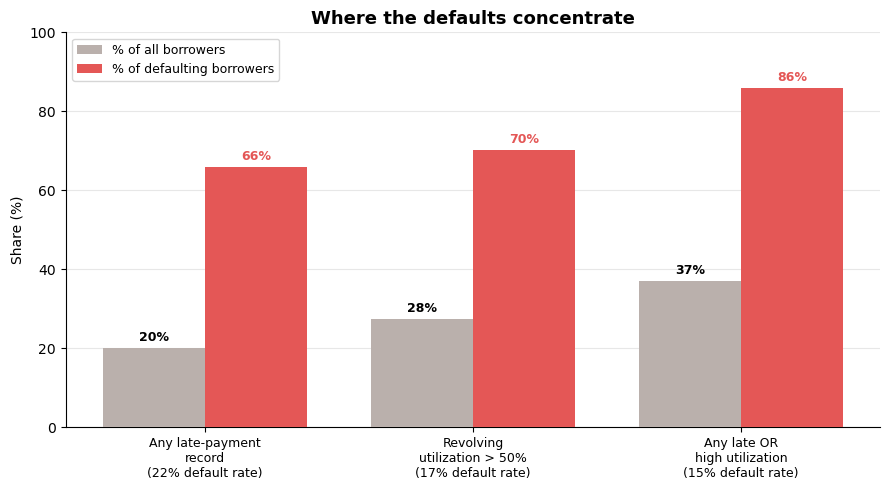

In [9]:
total_defaults = df_train["SeriousDlqin2yrs"].sum()
pastdue = ["NumberOfTime30-59DaysPastDueNotWorse",
           "NumberOfTime60-89DaysPastDueNotWorse",
           "NumberOfTimes90DaysLate"]
any_late  = (df_train[pastdue] > 0).any(axis=1)
high_util = df_train["RevolvingUtilizationOfUnsecuredLines"] > 0.5
segments = {
    "Any late-payment\nrecord":      any_late,
    "Revolving\nutilization > 50%":  high_util,
    "Any late OR\nhigh utilization": any_late | high_util,
}
rows = []
for label, mask in segments.items():
    rows.append({
        "segment":       label.replace("\n", " "),
        "pop_share":     mask.mean() * 100,
        "default_share": df_train.loc[mask, "SeriousDlqin2yrs"].sum() / total_defaults * 100,
        "default_rate":  df_train.loc[mask, "SeriousDlqin2yrs"].mean() * 100,
    })
conc = pd.DataFrame(rows)
print(conc.round(1).to_string(index=False))
# ---- viz: % of population vs % of all defaults ----
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(segments)); w = 0.38
pop = [m.mean() * 100 for m in segments.values()]
dfl = [df_train.loc[m, "SeriousDlqin2yrs"].sum() / total_defaults * 100 for m in segments.values()]
rates = [df_train.loc[m, "SeriousDlqin2yrs"].mean() * 100 for m in segments.values()]   # <-- added
ax.bar(x - w/2, pop, w, color="#BAB0AC", label="% of all borrowers", zorder=3)
ax.bar(x + w/2, dfl, w, color="#E45756", label="% of defaulting borrowers", zorder=3)
for xi, v in zip(x - w/2, pop):
    ax.text(xi, v + 1, f"{v:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold")
for xi, v in zip(x + w/2, dfl):
    ax.text(xi, v + 1, f"{v:.0f}%", ha="center", va="bottom", fontsize=9, fontweight="bold", color="#E45756")
ax.set_xticks(x)
ax.set_xticklabels([f"{k}\n({r:.0f}% default rate)" for k, r in zip(segments.keys(), rates)], fontsize=9)  # <-- changed
ax.set_ylabel("Share (%)"); ax.set_ylim(0, 100)
ax.set_title("Where the defaults concentrate", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="upper left"); ax.grid(axis="y", alpha=0.3, zorder=0)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()